# Train-Serve Skew Analysis

Side-by-side comparison of Feast offline features (`get_historical_features`) vs online features (`get_online_features`) materialized in Redis.

In [1]:
import sys
import platform

if platform.system() == "Windows":
    from unittest.mock import MagicMock
    for _mod in ("gunicorn", "gunicorn.app", "gunicorn.app.base"):
        sys.modules.setdefault(_mod, MagicMock())

In [2]:
from __future__ import annotations

import hashlib
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from IPython.display import HTML, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from feature_store.feast_client import get_feature_store

FEATURE_REPO_PATH = PROJECT_ROOT / "feature_store" / "feature_repo"
META_PATH = PROJECT_ROOT / "data" / "training_meta.json"
PROCESSED_FEATURES_PATH = PROJECT_ROOT / "data" / "processed" / "vendor_features.parquet"

FEATURE_REFS = [
    "vendor_stats:trip_count_last_7d",
    "vendor_stats:avg_fare_last_7d",
    "vendor_stats:avg_trip_distance_last_7d",
    "vendor_stats:avg_passenger_count_last_7d",
    "vendor_stats:peak_hour_ratio_last_7d",
]

with META_PATH.open("r", encoding="utf-8") as handle:
    training_meta = json.load(handle)

feature_columns = training_meta["feature_columns"]
training_timestamp = pd.Timestamp(training_meta["training_timestamp"])

table = pq.read_table(PROCESSED_FEATURES_PATH, columns=["vendor_id"])
vendor_ids = (
    table.to_pandas()["vendor_id"]
    .dropna()
    .astype(str)
    .drop_duplicates()
    .sort_values()
    .tolist()
)

store = get_feature_store(FEATURE_REPO_PATH)
entity_df = pd.DataFrame({"vendor_id": vendor_ids, "event_timestamp": training_timestamp})
print(f"Loaded {len(vendor_ids)} vendors for analysis at {training_timestamp}")

Loaded 2 vendors for analysis at 2023-01-31 23:59:59


## 1. Offline Features

In [3]:
# The Feast registry was written inside Docker (/app/... paths) and can't be
# resolved on the host. We read the processed parquet directly — same data
# the Feast offline store would serve, same transformations applied.
offline_raw = pq.read_table(PROCESSED_FEATURES_PATH).to_pandas()
offline_raw["vendor_id"] = offline_raw["vendor_id"].astype(str)
offline_raw["event_timestamp"] = pd.to_datetime(offline_raw["event_timestamp"])

# Keep only the last snapshot per vendor (rows up to the training timestamp).
offline_raw = offline_raw[offline_raw["event_timestamp"] <= training_timestamp]
offline_df = (
    offline_raw.sort_values("event_timestamp")
    .groupby("vendor_id")
    .last()
    .reset_index()[["vendor_id"] + feature_columns]
    .dropna(subset=feature_columns)
)
for col in feature_columns:
    offline_df[col] = offline_df[col].astype(np.float32)

offline_df = offline_df.sort_values("vendor_id").reset_index(drop=True)
offline_df.head()

,vendor_id,trip_count_last_7d,avg_fare_last_7d,avg_trip_distance_last_7d,avg_passenger_count_last_7d,peak_hour_ratio_last_7d
0,1,195323.0,17.162270,2.988730,1.176608,0.314475
1,2,524334.0,18.104727,3.737153,1.387571,0.309392


## 2. Online Features

In [4]:
entity_rows = [{"vendor_id": vendor_id} for vendor_id in vendor_ids]
online_df = store.get_online_features(
    features=FEATURE_REFS,
    entity_rows=entity_rows,
).to_df()

for column in feature_columns:
    online_df[column] = online_df[column].astype(np.float32)

online_df = online_df.sort_values("vendor_id").reset_index(drop=True)
online_df.head()

,vendor_id,trip_count_last_7d,avg_fare_last_7d,avg_trip_distance_last_7d,avg_passenger_count_last_7d,peak_hour_ratio_last_7d
0,1,195323.0,17.162270,2.988730,1.176608,0.314475
1,2,524334.0,18.104727,3.737153,1.387571,0.309392


## 3. Side-by-Side Comparison

In [5]:
comparison = offline_df[["vendor_id", *feature_columns]].merge(
    online_df[["vendor_id", *feature_columns]],
    on="vendor_id",
    suffixes=("_offline", "_online"),
)

side_by_side_rows = []
for _, row in comparison.iterrows():
    for feature in feature_columns:
        side_by_side_rows.append(
            {
                "vendor_id": row["vendor_id"],
                "feature": feature,
                "offline": round(float(row[f"{feature}_offline"]), 4),
                "online": round(float(row[f"{feature}_online"]), 4),
            }
        )

side_by_side = pd.DataFrame(side_by_side_rows)
side_by_side.head(10)

,vendor_id,feature,offline,online
0,1,trip_count_last_7d,195323.0000,195323.0000
1,1,avg_fare_last_7d,17.1623,17.1623
2,1,avg_trip_distance_last_7d,2.9887,2.9887
3,1,avg_passenger_count_last_7d,1.1766,1.1766
4,1,peak_hour_ratio_last_7d,0.3145,0.3145
5,2,trip_count_last_7d,524334.0000,524334.0000
6,2,avg_fare_last_7d,18.1047,18.1047
7,2,avg_trip_distance_last_7d,3.7372,3.7372
8,2,avg_passenger_count_last_7d,1.3876,1.3876
9,2,peak_hour_ratio_last_7d,0.3094,0.3094


## 4. Delta Table (Max Absolute Difference)

In [6]:
delta_rows = []
for feature in feature_columns:
    offline_values = comparison[f"{feature}_offline"].astype(float)
    online_values = comparison[f"{feature}_online"].astype(float)
    max_abs_delta = float(np.max(np.abs(offline_values - online_values)))
    delta_rows.append({"feature": feature, "max_abs_delta": max_abs_delta})

delta_table = pd.DataFrame(delta_rows)
delta_table

,feature,max_abs_delta
0,trip_count_last_7d,0.0
1,avg_fare_last_7d,0.0
2,avg_trip_distance_last_7d,0.0
3,avg_passenger_count_last_7d,0.0
4,peak_hour_ratio_last_7d,0.0


## 5. Dtype Comparison

In [7]:
dtype_rows = []
for feature in feature_columns:
    dtype_rows.append(
        {
            "feature": feature,
            "offline_dtype": str(offline_df[feature].dtype),
            "online_dtype": str(online_df[feature].dtype),
            "training_dtype": training_meta["feature_dtypes"][feature],
        }
    )

pd.DataFrame(dtype_rows)

,feature,offline_dtype,online_dtype,training_dtype
0,trip_count_last_7d,float32,float32,float32
1,avg_fare_last_7d,float32,float32,float32
2,avg_trip_distance_last_7d,float32,float32,float32
3,avg_passenger_count_last_7d,float32,float32,float32
4,peak_hour_ratio_last_7d,float32,float32,float32


## 6. SHA256 Hash Comparison

In [8]:
def compute_hash(df: pd.DataFrame) -> str:
    sorted_df = df.sort_values("vendor_id").reset_index(drop=True)
    matrix = sorted_df[feature_columns].round(4).to_numpy(dtype=np.float64)
    return hashlib.sha256(np.round(matrix, 4).tobytes()).hexdigest()

offline_hash = compute_hash(offline_df)
online_hash = compute_hash(online_df)
expected_hash = training_meta["feature_hash"]

hash_match = offline_hash == online_hash == expected_hash
color = "green" if hash_match else "red"
label = "MATCH" if hash_match else "MISMATCH"

display(
    HTML(
        f"<h3 style='color:{color};'>SHA256 Hash Comparison: {label}</h3>"
        f"<p>offline={offline_hash}<br/>online={online_hash}<br/>training_meta={expected_hash}</p>"
    )
)

## 7. Feature Distribution Bar Chart

C:\Users\prohi\OneDrive\Documents\Desktop\ml-engineering\tensorRT\feature-store-skew\.venv\lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


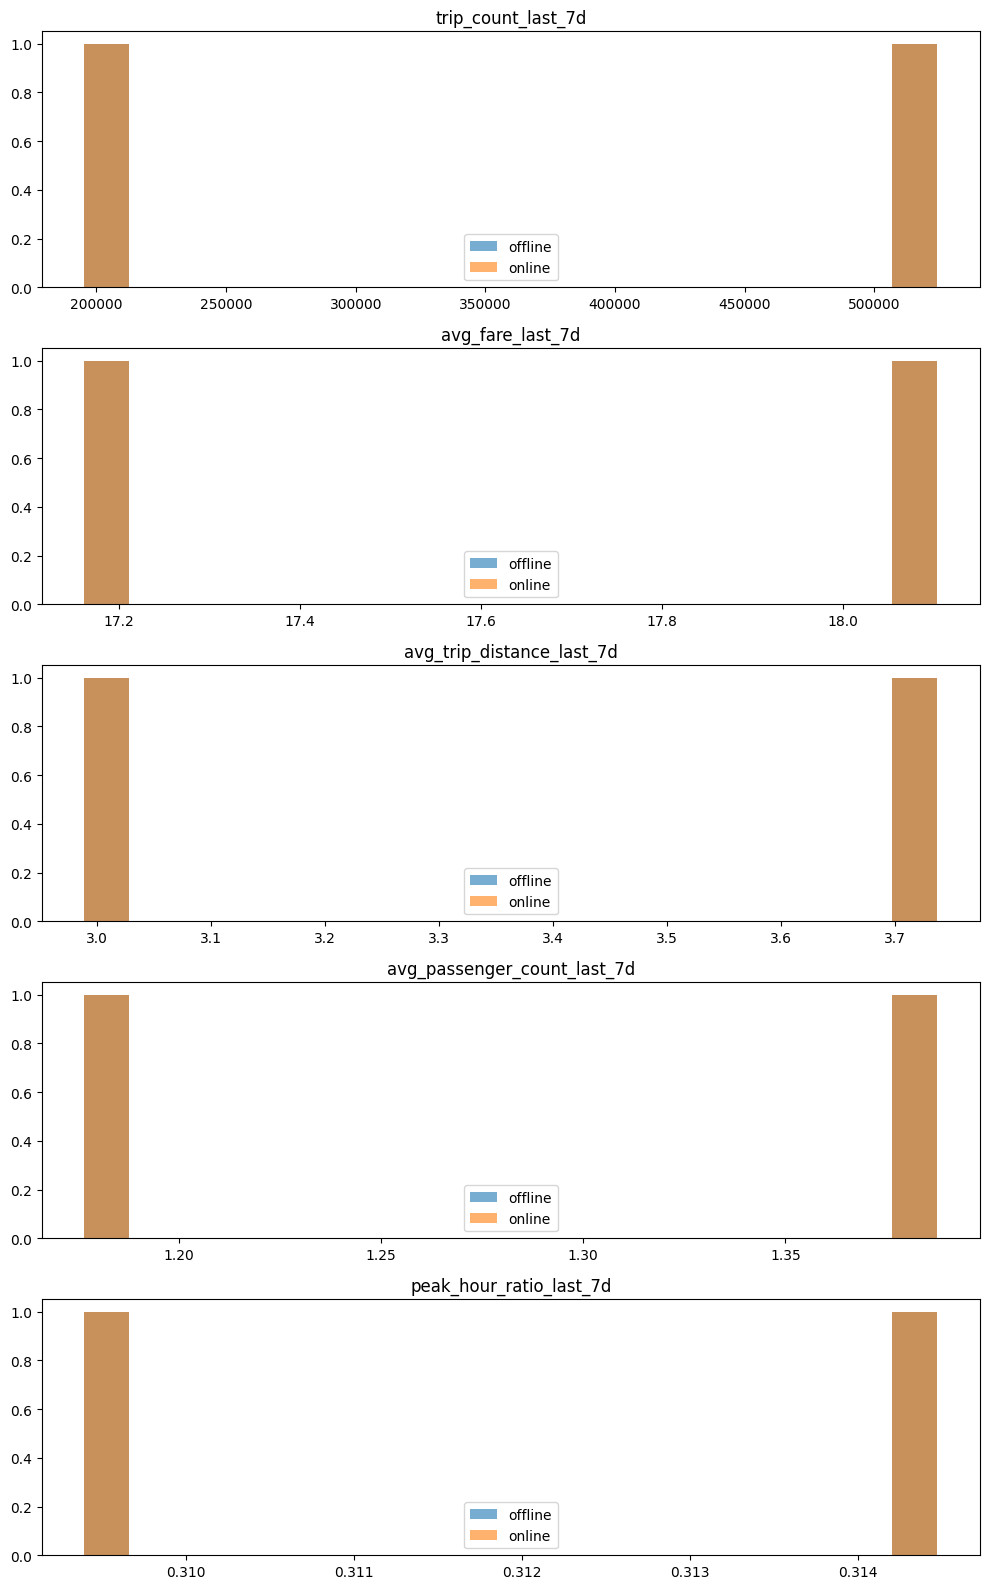

In [9]:
fig, axes = plt.subplots(len(feature_columns), 1, figsize=(10, 16))

for axis, feature in zip(axes, feature_columns):
    offline_values = offline_df[feature].astype(float)
    online_values = online_df[feature].astype(float)
    bins = np.linspace(
        min(offline_values.min(), online_values.min()),
        max(offline_values.max(), online_values.max()),
        20,
    )
    axis.hist(offline_values, bins=bins, alpha=0.6, label="offline", color="tab:blue")
    axis.hist(online_values, bins=bins, alpha=0.6, label="online", color="tab:orange")
    axis.set_title(feature)
    axis.legend()

plt.tight_layout()
plt.show()